In [22]:
# first of all import all the required libraries

In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [24]:
# create one dataset

In [25]:
data = {
    "Math_Score": [90, 85, 70, 60, 95, 40, 30, 88, 75, 65],
    "Logic_Score": [92, 80, 65, 55, 90, 45, 35, 85, 70, 60],
    "Communication": [60, 55, 70, 80, 50, 90, 85, 58, 65, 75],
    "Career": [
        "Engineer", "Engineer", "Engineer",
        "Manager", "Engineer", "HR",
        "HR", "Engineer", "Engineer", "Manager"
    ]
}

In [26]:
df = pd.DataFrame(data)
print(df)

   Math_Score  Logic_Score  Communication    Career
0          90           92             60  Engineer
1          85           80             55  Engineer
2          70           65             70  Engineer
3          60           55             80   Manager
4          95           90             50  Engineer
5          40           45             90        HR
6          30           35             85        HR
7          88           85             58  Engineer
8          75           70             65  Engineer
9          65           60             75   Manager


In [27]:
# Step 3: Separate Features & Target

In [28]:
X = df.drop("Career", axis=1)  ## this code line means drop career column from df and take all remaining columns as an input
y = df["Career"]

In [29]:
# Step 4: Train-Test Split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
# Step 5: Build Decision Tree Model

In [32]:
model = DecisionTreeClassifier(
    criterion="gini",    # or "entropy"
    max_depth=3,
    random_state=42
)
## creating object of model

In [33]:
# Step 6: Train the Model

In [34]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [35]:
# Step 7: Predictions/ testing the model

In [36]:
y_pred = model.predict(X_test)
print("Predictions:", y_pred)

Predictions: ['Engineer' 'Engineer']


In [37]:
# Step 8: Model Evaluation

In [38]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

    Engineer       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


Confusion Matrix:
 [[2]]


C:\annaconda\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [39]:
# Step 9: Visualize Decision Tree

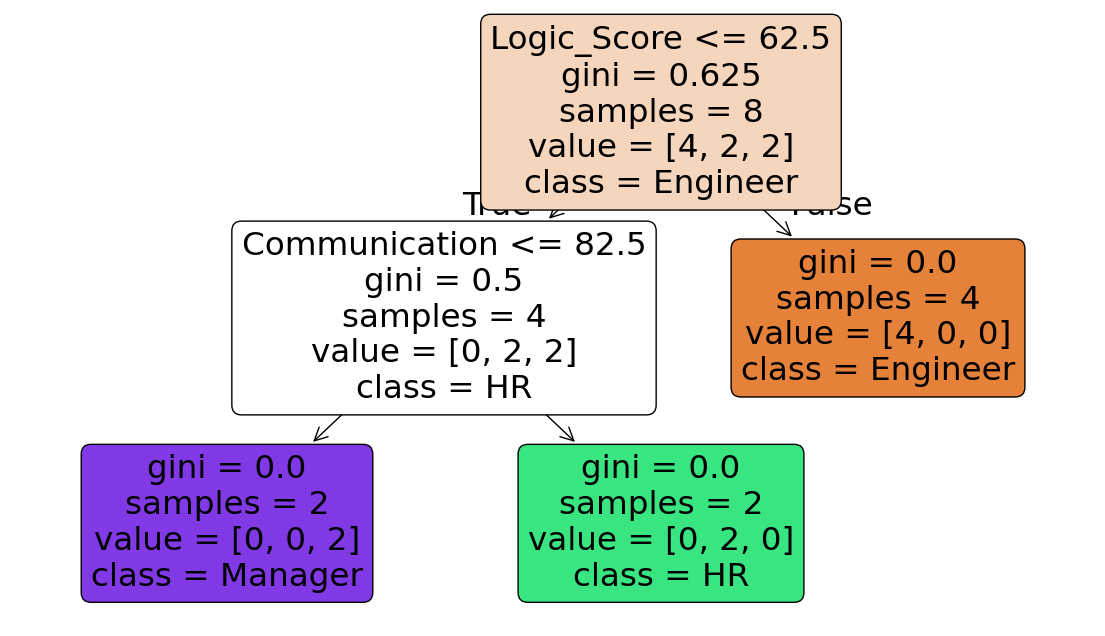

In [40]:
plt.figure(figsize=(14, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True
)
plt.show()

In [41]:
# Step 10: Predict for New Data

In [42]:
new_student = pd.DataFrame({
    "Math_Score": [],
    "Logic_Score": [82],
    "Communication": [65]
})

prediction = model.predict(new_student)
print("Predicted Car:", prediction[0])

Predicted Career: Engineer
